# 🦸 Jupyter Notebook — Heróis Marvel & DC

Notebook gerado automaticamente pelo instalador.
Use os heróis da Marvel e DC para aprender pandas, gráficos, CRUD e PySpark.

---


## 📦 Imports


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('✅ Imports OK')
print('pandas     :', pd.__version__)
print('numpy      :', np.__version__)
print('seaborn    :', sns.__version__)


✅ Imports OK
pandas     : 3.0.3
numpy      : 2.4.6
seaborn    : 0.13.2


---
## 📄 Leitura dos CSVs

Vamos carregar os arquivos da pasta `notebooks/`.


In [2]:
from pathlib import Path

def resolver_base_dados():
    candidatos = [
        Path.cwd() / 'notebooks',
        Path.cwd(),
    ]
    for base in candidatos:
        if (base / 'herois_marvel.csv').exists() and (base / 'herois_dc.csv').exists():
            return base
    return Path.cwd()

base = resolver_base_dados()
print('Base de dados:', base)

df_marvel = pd.read_csv(base / 'herois_marvel.csv')
df_dc     = pd.read_csv(base / 'herois_dc.csv')
df        = pd.concat([df_marvel, df_dc], ignore_index=True)

print(f'✅ Total: {len(df)} heróis carregados')
print(f'   Marvel: {len(df_marvel)} | DC: {len(df_dc)}')
df.head(10)


Base de dados: /home/paulo/Documentos/Git/MiscellaneousStudies/MiscellaneousStudies/script/notebooks
✅ Total: 30 heróis carregados
   Marvel: 15 | DC: 15


,nome,alter_ego,universo,poder_principal,forca,inteligencia,velocidade,equipe,ativo
0,Homem de Ferro,Tony Stark,Marvel,Armadura tecnológica,85,98,70,Vingadores,True
1,Capitão América,Steve Rogers,Marvel,Super soldado,95,75,65,Vingadores,True
2,Thor,Thor Odinson,Marvel,Controle do trovão,100,80,90,Vingadores,True
3,Hulk,Bruce Banner,Marvel,Força bruta,150,90,60,Vingadores,True
4,Homem-Aranha,Peter Parker,Marvel,Agilidade e teia,70,85,80,Vingadores,True
5,Viúva Negra,Natasha Romanoff,Marvel,Combate e espionagem,60,88,75,Vingadores,True
6,Pantera Negra,T'Challa,Marvel,Vibranium,80,85,78,Vingadores,True
7,Doutor Estranho,Stephen Strange,Marvel,Magia e feitiçaria,65,99,50,Vingadores,True
8,Star-Lord,Peter Quill,Marvel,Combate espacial,68,70,72,Guardiões,True
9,Wolverine,James Howlett,Marvel,Regeneração e garras,88,70,65,X-Men,True


---
## 🔍 Exploração


In [3]:
print(f'Shape   : {df.shape}')
print(f'Colunas : {list(df.columns)}')
print()
df[['forca', 'inteligencia', 'velocidade']].describe().round(1)


Shape   : (30, 9)
Colunas : ['nome', 'alter_ego', 'universo', 'poder_principal', 'forca', 'inteligencia', 'velocidade', 'equipe', 'ativo']



,forca,inteligencia,velocidade
count,30.0,30.0,30.0
mean,83.2,84.8,78.3
std,27.1,8.9,25.9
min,50.0,65.0,50.0
25%,65.0,80.0,68.0
50%,72.0,85.0,73.5
75%,93.8,90.0,85.0
max,150.0,99.0,200.0


---
## 🔎 READ — Filtros e consultas


In [4]:
# Heróis Marvel
marvel = df[df['universo'] == 'Marvel']
print(f'Marvel: {len(marvel)} heróis')
marvel[['nome', 'alter_ego', 'poder_principal']].head(8)


Marvel: 15 heróis


,nome,alter_ego,poder_principal
0,Homem de Ferro,Tony Stark,Armadura tecnológica
1,Capitão América,Steve Rogers,Super soldado
2,Thor,Thor Odinson,Controle do trovão
3,Hulk,Bruce Banner,Força bruta
4,Homem-Aranha,Peter Parker,Agilidade e teia
5,Viúva Negra,Natasha Romanoff,Combate e espionagem
6,Pantera Negra,T'Challa,Vibranium
7,Doutor Estranho,Stephen Strange,Magia e feitiçaria


In [5]:
# Heróis com força > 90
super_fortes = df[df['forca'] > 90].sort_values('forca', ascending=False)
print(f'Heróis com força > 90: {len(super_fortes)}')
super_fortes[['nome', 'universo', 'forca', 'poder_principal']]


Heróis com força > 90: 8


,nome,universo,forca,poder_principal
15,Superman,DC,150,Superforça e voo
3,Hulk,Marvel,150,Força bruta
21,Shazam,DC,130,Poderes mágicos e força
17,Mulher Maravilha,DC,120,Combate e força divina
28,Martian Manhunter,DC,115,Telepatia e forma variável
19,Aquaman,DC,110,Controle dos mares
2,Thor,Marvel,100,Controle do trovão
1,Capitão América,Marvel,95,Super soldado


In [6]:
# Mais inteligente por universo
mais_intel = df.loc[df.groupby('universo')['inteligencia'].idxmax()]
print('🧠 Mais inteligente por universo:')
mais_intel[['universo', 'nome', 'inteligencia', 'poder_principal']]


🧠 Mais inteligente por universo:


,universo,nome,inteligencia,poder_principal
16,DC,Batman,99,Inteligência e gadgets
7,Marvel,Doutor Estranho,99,Magia e feitiçaria


---
## ➕ CREATE — Adicionando novos heróis


In [7]:
novos = pd.DataFrame([
    {
        'nome': 'Deadpool',
        'alter_ego': 'Wade Wilson',
        'universo': 'Marvel',
        'poder_principal': 'Regeneração e humor',
        'forca': 75,
        'inteligencia': 72,
        'velocidade': 70,
        'equipe': 'Solo',
        'ativo': True
    },
    {
        'nome': 'Supergirl',
        'alter_ego': 'Kara Zor-El',
        'universo': 'DC',
        'poder_principal': 'Superforça e voo',
        'forca': 140,
        'inteligencia': 88,
        'velocidade': 92,
        'equipe': 'Liga da Justiça',
        'ativo': True
    },
    {
        'nome': 'Capitã Marvel',
        'alter_ego': 'Carol Danvers',
        'universo': 'Marvel',
        'poder_principal': 'Absorção de energia',
        'forca': 130,
        'inteligencia': 85,
        'velocidade': 95,
        'equipe': 'Vingadores',
        'ativo': True
    }
])

df = pd.concat([df, novos], ignore_index=True)
print(f'✅ {len(novos)} heróis adicionados! Total: {len(df)}')
df.tail(4)


✅ 3 heróis adicionados! Total: 33


,nome,alter_ego,universo,poder_principal,forca,inteligencia,velocidade,equipe,ativo
29,Zatanna,Zatanna Zatara,DC,Magia,60,90,70,Liga da Justiça,True
30,Deadpool,Wade Wilson,Marvel,Regeneração e humor,75,72,70,Solo,True
31,Supergirl,Kara Zor-El,DC,Superforça e voo,140,88,92,Liga da Justiça,True
32,Capitã Marvel,Carol Danvers,Marvel,Absorção de energia,130,85,95,Vingadores,True


---
## ✏️ UPDATE — Atualizando dados


In [8]:
print('Antes:')
print(df[df['nome'] == 'Hulk'][['nome', 'forca', 'inteligencia']])

df.loc[df['nome'] == 'Hulk', 'forca'] = 180
df.loc[df['nome'] == 'Hulk', 'inteligencia'] = 95

print()
print('Depois:')
print(df[df['nome'] == 'Hulk'][['nome', 'forca', 'inteligencia']])


Antes:
   nome  forca  inteligencia
3  Hulk    150            90

Depois:
   nome  forca  inteligencia
3  Hulk    180            95


In [9]:
# Coluna calculada: poder_geral
df['poder_geral'] = ((df['forca'] + df['inteligencia'] + df['velocidade']) / 3).round(1)
print('✅ Coluna poder_geral criada!')
df[['nome', 'universo', 'forca', 'inteligencia', 'velocidade', 'poder_geral']] \
    .sort_values('poder_geral', ascending=False).head(10)


✅ Coluna poder_geral criada!


,nome,universo,forca,inteligencia,velocidade,poder_geral
18,Flash,DC,55,85,200,113.3
15,Superman,DC,150,90,95,111.7
3,Hulk,Marvel,180,95,60,111.7
31,Supergirl,DC,140,88,92,106.7
32,Capitã Marvel,Marvel,130,85,95,103.3
21,Shazam,DC,130,80,90,100.0
28,Martian Manhunter,DC,115,95,88,99.3
17,Mulher Maravilha,DC,120,88,85,97.7
19,Aquaman,DC,110,80,88,92.7
2,Thor,Marvel,100,80,90,90.0


---
## ❌ DELETE — Removendo registros


In [10]:
print(f'Total antes: {len(df)}')
df = df[df['equipe'] != 'Vilões'].reset_index(drop=True)
print(f'Total depois: {len(df)}')
print('✅ Vilões removidos!')


Total antes: 33
Total depois: 31
✅ Vilões removidos!


In [11]:
df = df.drop(columns=['ativo'])
print('Colunas:', list(df.columns))


Colunas: ['nome', 'alter_ego', 'universo', 'poder_principal', 'forca', 'inteligencia', 'velocidade', 'equipe', 'poder_geral']


---
## 💾 Salvando o resultado final


In [12]:
output = base / 'herois_final.csv'
df.to_csv(output, index=False)
df_check = pd.read_csv(output)
print(f'✅ Salvo em: {output}')
print(f'   Total: {len(df_check)} heróis')


✅ Salvo em: /home/paulo/Documentos/Git/MiscellaneousStudies/MiscellaneousStudies/script/notebooks/herois_final.csv
   Total: 31 heróis


---
## 📊 Visualizações — Marvel vs DC


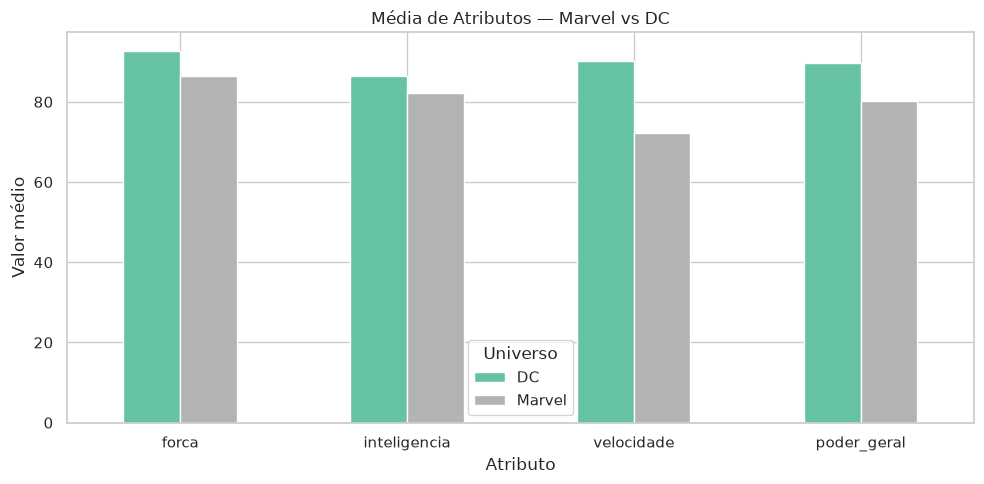

          forca  inteligencia  velocidade  poder_geral
universo                                              
DC         92.7          86.5        90.2         89.8
Marvel     86.4          82.2        72.2         80.2


In [13]:
medias = df.groupby('universo')[['forca', 'inteligencia', 'velocidade', 'poder_geral']].mean().round(1)
medias.T.plot(kind='bar', colormap='Set2', rot=0)
plt.title('Média de Atributos — Marvel vs DC')
plt.xlabel('Atributo')
plt.ylabel('Valor médio')
plt.legend(title='Universo')
plt.tight_layout()
plt.show()
print(medias)


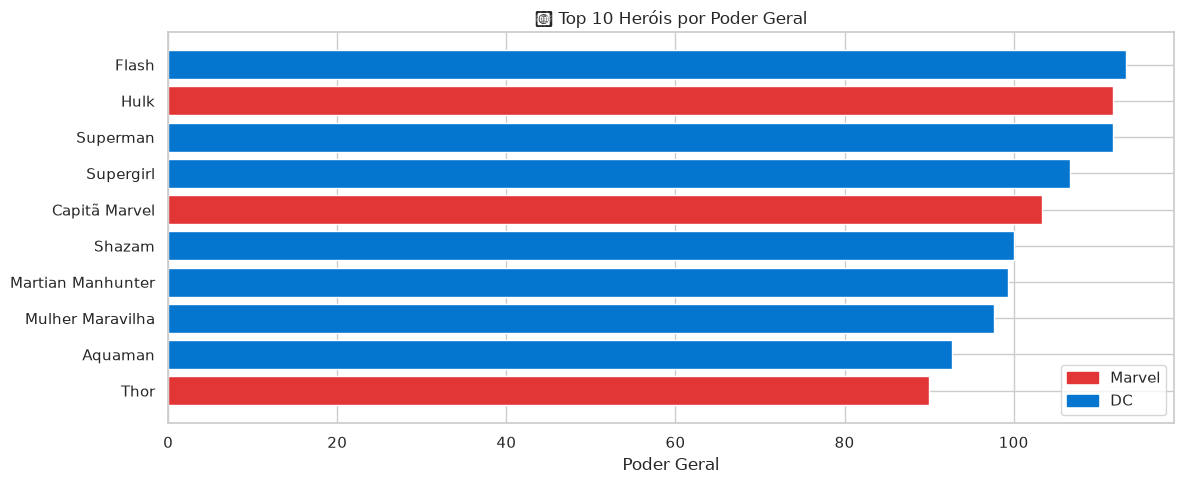

In [14]:
top10 = df.nlargest(10, 'poder_geral')
cores = ['#E23636' if u == 'Marvel' else '#0476D0' for u in top10['universo']]

plt.figure(figsize=(12, 5))
plt.barh(top10['nome'], top10['poder_geral'], color=cores)
plt.xlabel('Poder Geral')
plt.title('🏆 Top 10 Heróis por Poder Geral')
plt.gca().invert_yaxis()

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color='#E23636', label='Marvel'),
    Patch(color='#0476D0', label='DC')
])
plt.tight_layout()
plt.show()


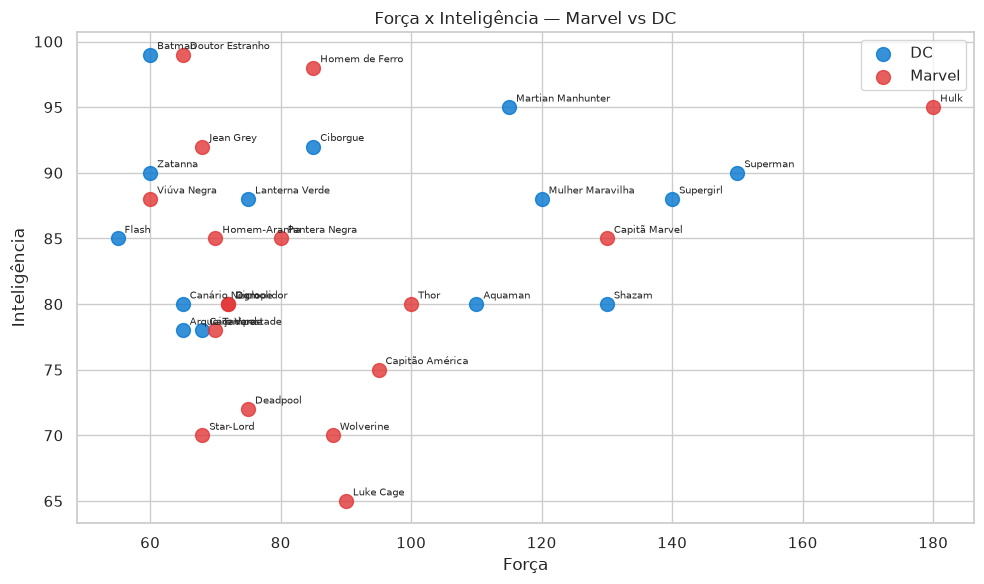

In [15]:
plt.figure(figsize=(10, 6))
for universo, grupo in df.groupby('universo'):
    cor = '#E23636' if universo == 'Marvel' else '#0476D0'
    plt.scatter(grupo['forca'], grupo['inteligencia'],
                label=universo, color=cor, s=100, alpha=0.8)
    for _, row in grupo.iterrows():
        plt.annotate(row['nome'], (row['forca'], row['inteligencia']),
                     textcoords='offset points', xytext=(5, 4), fontsize=7)

plt.xlabel('Força')
plt.ylabel('Inteligência')
plt.title('Força x Inteligência — Marvel vs DC')
plt.legend()
plt.tight_layout()
plt.show()


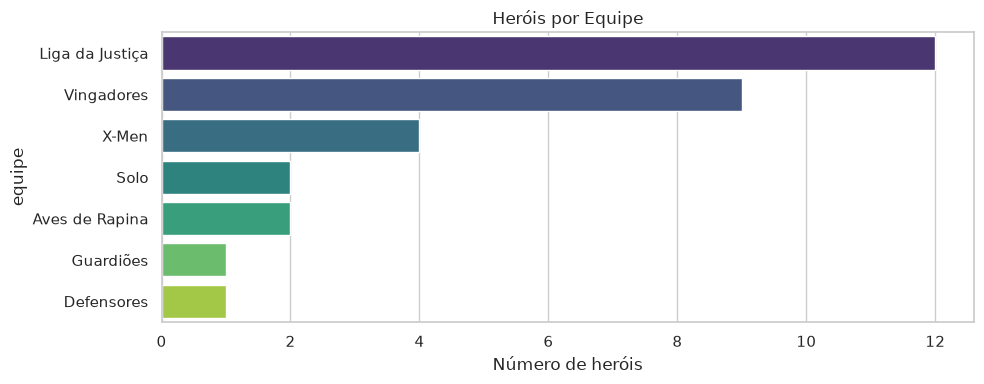

In [16]:
equipes = df['equipe'].value_counts()
plt.figure(figsize=(10, 4))
sns.barplot(x=equipes.values, y=equipes.index, palette='viridis')
plt.xlabel('Número de heróis')
plt.title('Heróis por Equipe')
plt.tight_layout()
plt.show()


---
## ⚡ PySpark — Heróis com Big Data


In [17]:
import os, subprocess

try:
    r = subprocess.run(
        'dirname $(dirname $(readlink -f $(which java)))',
        shell=True, capture_output=True, text=True
    )
    jh = r.stdout.strip()
    if jh:
        os.environ['JAVA_HOME']      = jh
        os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'
        os.environ['PATH']           = jh + '/bin:' + os.environ.get('PATH', '')
        print('JAVA_HOME:', jh)
except Exception as e:
    print('Aviso:', e)

import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, round as spark_round

spark = SparkSession.builder \
    .appName('herois_marvel_dc') \
    .master('local[*]') \
    .config('spark.driver.host', '127.0.0.1') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print('✅ Spark iniciado! Versão:', spark.version)


JAVA_HOME: /home/paulo/.sdkman/candidates/java/21.0.3-tem


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/10 08:53:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/10 08:53:53 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


TypeError: 'JavaPackage' object is not callable

In [ ]:
csv_final = str(base / 'herois_final.csv')

df_spark = spark.read \
    .option('header', 'true') \
    .option('inferSchema', 'true') \
    .csv(csv_final)

print(f'Total: {df_spark.count()} heróis')
df_spark.show(5)


In [18]:
print('📊 Médias por universo:')
df_spark.groupBy('universo').agg(
    spark_round(avg(col('forca')), 1).alias('media_forca'),
    spark_round(avg(col('inteligencia')), 1).alias('media_intel'),
    spark_round(avg(col('velocidade')), 1).alias('media_vel'),
    spark_round(avg(col('poder_geral')), 1).alias('media_poder')
).show()


📊 Médias por universo:


NameError: name 'df_spark' is not defined

In [19]:
df_spark.createOrReplaceTempView('herois')
print('🏆 Top 5 por poder geral (Spark SQL):')
spark.sql("""
    SELECT nome, universo, equipe, poder_geral
    FROM herois
    ORDER BY poder_geral DESC
    LIMIT 5
""").show()


NameError: name 'df_spark' is not defined

---
## 🤖 scikit-learn — Prevendo o poder de um herói


In [20]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['forca', 'inteligencia', 'velocidade']].values
y = df['poder_geral'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print('scikit-learn versão:', sklearn.__version__)
print(f'MAE : {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R²  : {r2_score(y_test, y_pred):.4f}')

novo = [[100, 95, 90]]
print(f'\n🦸 Previsão para forca=100, intel=95, vel=90: {modelo.predict(novo)[0]:.1f}')


scikit-learn versão: 1.9.0
MAE : 0.03
R²  : 1.0000

🦸 Previsão para forca=100, intel=95, vel=90: 95.0


26/07/10 08:54:06 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


---
## ✅ Tudo funcionando!

| Tópico | O que foi feito |
|---|---|
| **Leitura CSV** | `pd.read_csv()` com Marvel e DC |
| **Exploração** | `.shape`, `.dtypes`, `.describe()` |
| **READ** | Filtros, `.groupby()`, `.sort_values()` |
| **CREATE** | `pd.concat()` com novos heróis |
| **UPDATE** | `.loc[]` para atualizar e criar colunas |
| **DELETE** | Remoção de linhas e colunas |
| **Exportar CSV** | `.to_csv()` |
| **Gráficos** | Barras, dispersão e distribuição |
| **PySpark** | Leitura, agregação e Spark SQL |
| **scikit-learn** | Regressão linear |

**Próximos passos:** importe seus próprios dados e explore! 🚀
